# Overview: one library, many scientific plots

A compact tour across line, distribution, categorical, and matrix plots.

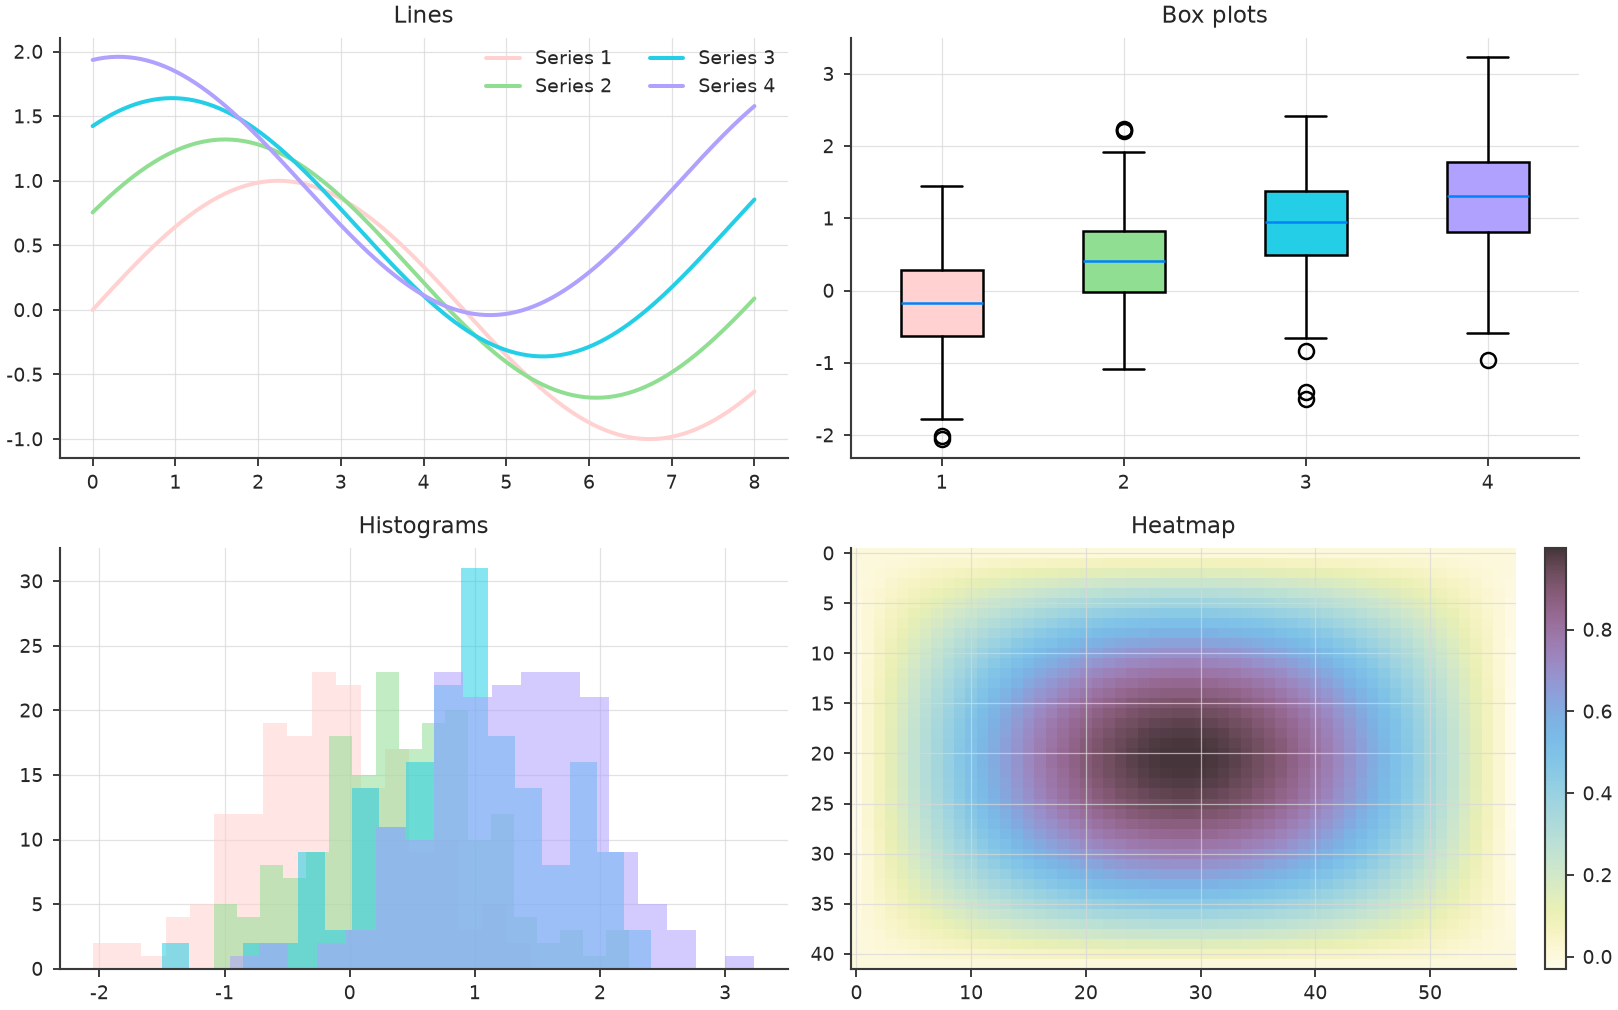

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contrastcolors as cc

cc.set_style("heri", font="DejaVu Sans")
rng = np.random.default_rng(10)
colors = cc.color_palette(hues=[20,145,210,290], ratio=1.18, start_luminance=0.72)
fig, axes = plt.subplots(2, 2, figsize=(9.2, 5.8))

x = np.linspace(0, 8, 220)
for i, color in enumerate(colors):
    axes[0,0].plot(x, np.sin(x*0.7+i*0.45)+i*0.32, color=color, label=f"Series {i+1}")
axes[0,0].set_title("Lines")
axes[0,0].legend(ncol=2)

samples=[rng.normal(i*0.45,0.7,180) for i in range(4)]
bp=axes[0,1].boxplot(samples, patch_artist=True)
for patch,color in zip(bp["boxes"],colors):
    patch.set_facecolor(color)
axes[0,1].set_title("Box plots")

for i,(sample,color) in enumerate(zip(samples,colors)):
    axes[1,0].hist(sample,bins=18,alpha=0.55,color=color,label=f"G{i+1}")
axes[1,0].set_title("Histograms")

z=np.outer(np.sin(np.linspace(0,np.pi,42)),np.cos(np.linspace(-1.6,1.6,58)))
im=axes[1,1].imshow(z,cmap=cc.HERI_CMAP,aspect="auto")
axes[1,1].set_title("Heatmap")
fig.colorbar(im,ax=axes[1,1],fraction=0.046,pad=0.04)
fig.tight_layout()

In [ ]:
cc.show_accessibility_panel(fig, max_width=640)
plt.show()